# ResNet-50 vs MambaVision Metrics Comparison

Put these archives in the repository root or upload them to the notebook runtime:

- `resnet50_final_light.zip`
- `mambavision_15ep_b32_final_light(1).zip`

The notebook extracts both archives, compares summary metrics, per-class object metrics, per-weather metrics, and training loss curves.

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
RESNET_ZIP = ROOT / "resnet50_final_light.zip"
MAMBA_ZIP = ROOT / "mambavision_15ep_b32_final_light(1).zip"

for path in [RESNET_ZIP, MAMBA_ZIP]:
    print(path, "exists=", path.exists(), "size=", path.stat().st_size if path.exists() else None)
    assert path.exists(), f"Missing archive: {path}"

/content/resnet50_final_light.zip exists= True size= 312130
/content/mambavision_15ep_b32_final_light(1).zip exists= True size= 335149


## Extract Archives

In [2]:
OUT_DIR = ROOT / "comparison_outputs"
RESNET_DIR = OUT_DIR / "resnet50"
MAMBA_DIR = OUT_DIR / "mambavision"

for archive, target in [(RESNET_ZIP, RESNET_DIR), (MAMBA_ZIP, MAMBA_DIR)]:
    target.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(target)
    print("Extracted", archive.name, "->", target)

Extracted resnet50_final_light.zip -> /content/comparison_outputs/resnet50
Extracted mambavision_15ep_b32_final_light(1).zip -> /content/comparison_outputs/mambavision


## Load Metrics

In [3]:
MODELS = {
    "resnet50": {
        "root": RESNET_DIR,
        "prefix": "resnet50_full_val",
        "history": "resnet50_full_history.csv",
    },
    "mambavision_t_15ep_b32": {
        "root": MAMBA_DIR,
        "prefix": "mamba_t_15ep_b32_val",
        "history": "mamba_t_15ep_b32_history.csv",
    },
}

def metrics_path(spec, suffix):
    return spec["root"] / "reports" / "metrics" / f"{spec['prefix']}{suffix}"

records = []
per_class = {}
per_weather = {}
histories = {}

for model_name, spec in MODELS.items():
    with metrics_path(spec, ".json").open(encoding="utf-8") as f:
        raw = json.load(f)

    records.append({
        "model": model_name,
        "samples": raw["num_samples"],
        "weather_accuracy": raw["weather"]["accuracy"],
        "weather_macro_f1": raw["weather"]["macro_f1"],
        "object_mAP": raw["objects"]["mAP"],
        "object_macro_f1": raw["objects"]["macro_f1"],
        "object_hamming_loss": raw["objects"]["hamming_loss"],
    })

    per_class[model_name] = pd.read_csv(metrics_path(spec, ".per_class.csv"))
    per_weather[model_name] = pd.read_csv(metrics_path(spec, ".per_weather.csv"))
    histories[model_name] = pd.read_csv(spec["root"] / "reports" / "metrics" / spec["history"])

summary = pd.DataFrame(records).set_index("model")
summary

,samples,weather_accuracy,weather_macro_f1,object_mAP,object_macro_f1,object_hamming_loss
model,,,,,,
resnet50,320,0.98750,0.987499,0.727999,0.727626,0.170660
mambavision_t_15ep_b32,320,0.96875,0.968808,0.692913,0.707608,0.200174


## Summary Comparison

In [4]:
delta = summary.loc["mambavision_t_15ep_b32"] - summary.loc["resnet50"]
comparison = summary.T
comparison["mamba_minus_resnet"] = delta
comparison

model,resnet50,mambavision_t_15ep_b32,mamba_minus_resnet
samples,320.000000,320.000000,0.000000
weather_accuracy,0.987500,0.968750,-0.018750
weather_macro_f1,0.987499,0.968808,-0.018691
object_mAP,0.727999,0.692913,-0.035086
object_macro_f1,0.727626,0.707608,-0.020018
object_hamming_loss,0.170660,0.200174,0.029514


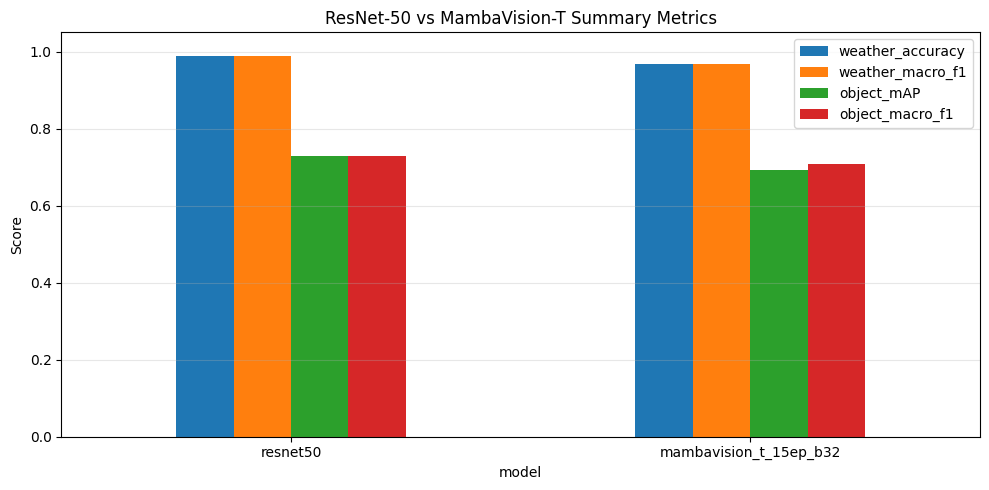

In [5]:
plot_metrics = [
    "weather_accuracy",
    "weather_macro_f1",
    "object_mAP",
    "object_macro_f1",
]

ax = summary[plot_metrics].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ResNet-50 vs MambaVision-T Summary Metrics")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_DIR / "summary_metrics_comparison.png", dpi=200)
plt.show()

## Per-Class Object Comparison

In [6]:
res_cls = per_class["resnet50"].rename(columns={
    "f1": "resnet_f1",
    "average_precision": "resnet_ap",
})[["class", "support", "resnet_f1", "resnet_ap"]]

mamba_cls = per_class["mambavision_t_15ep_b32"].rename(columns={
    "f1": "mamba_f1",
    "average_precision": "mamba_ap",
})[["class", "mamba_f1", "mamba_ap"]]

class_cmp = res_cls.merge(mamba_cls, on="class")
class_cmp["delta_f1"] = class_cmp["mamba_f1"] - class_cmp["resnet_f1"]
class_cmp["delta_ap"] = class_cmp["mamba_ap"] - class_cmp["resnet_ap"]
class_cmp = class_cmp.sort_values("delta_ap", ascending=False)
class_cmp.to_csv(OUT_DIR / "per_class_comparison.csv", index=False)
class_cmp

,class,support,resnet_f1,resnet_ap,mamba_f1,mamba_ap,delta_f1,delta_ap
14,bus,26,0.285714,0.178892,0.281250,0.192600,-0.004464,0.013708
10,person,123,0.677215,0.670457,0.672840,0.670462,-0.004376,0.000005
9,sky,320,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
1,building,284,0.980668,0.996876,0.968531,0.996753,-0.012136,-0.000123
7,vegetation,315,0.992126,0.998843,0.992126,0.998200,0.000000,-0.000643
4,pole,319,0.998435,0.999681,0.998435,0.998994,0.000000,-0.000687
0,sidewalk,275,0.963093,0.989021,0.954064,0.987252,-0.009030,-0.001769
6,traffic_sign,298,0.967213,0.975787,0.965854,0.973253,-0.001359,-0.002534
12,car,310,0.984127,0.992808,0.984127,0.985172,0.000000,-0.007636
3,fence,197,0.769556,0.756241,0.765625,0.745189,-0.003931,-0.011052


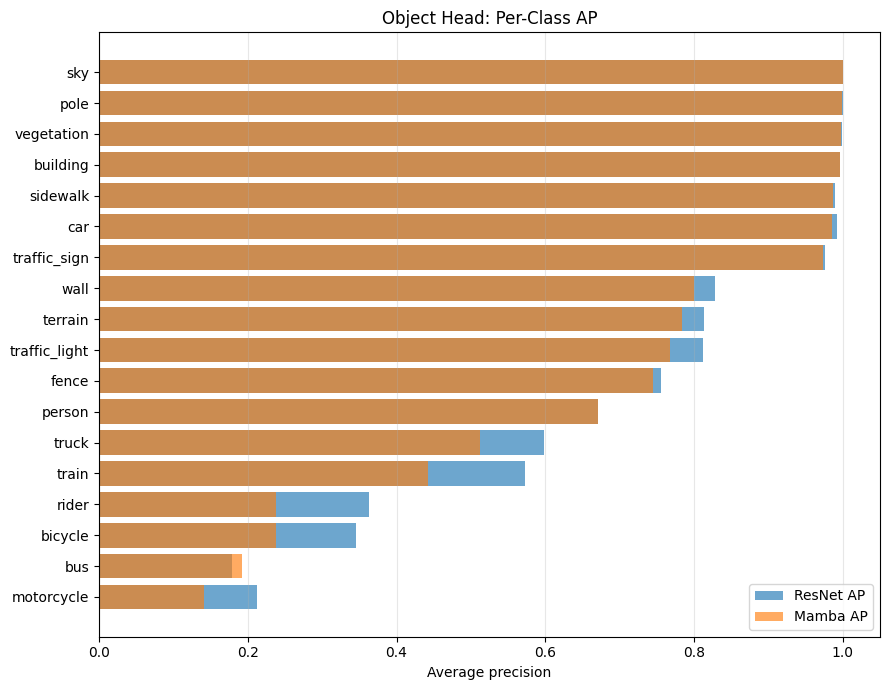

In [7]:
ordered = class_cmp.sort_values("mamba_ap", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(ordered["class"], ordered["resnet_ap"], alpha=0.65, label="ResNet AP")
ax.barh(ordered["class"], ordered["mamba_ap"], alpha=0.65, label="Mamba AP")
ax.set_xlabel("Average precision")
ax.set_title("Object Head: Per-Class AP")
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "per_class_ap_comparison.png", dpi=200)
plt.show()

## Per-Weather Object Comparison

In [8]:
res_weather = per_weather["resnet50"].rename(columns={
    "object_mAP": "resnet_object_mAP",
    "object_macro_f1": "resnet_object_macro_f1",
    "object_hamming_loss": "resnet_object_hamming_loss",
})

mamba_weather = per_weather["mambavision_t_15ep_b32"].rename(columns={
    "object_mAP": "mamba_object_mAP",
    "object_macro_f1": "mamba_object_macro_f1",
    "object_hamming_loss": "mamba_object_hamming_loss",
})

weather_cmp = res_weather.merge(mamba_weather, on=["weather", "num_samples"])
weather_cmp["delta_object_mAP"] = weather_cmp["mamba_object_mAP"] - weather_cmp["resnet_object_mAP"]
weather_cmp["delta_object_macro_f1"] = weather_cmp["mamba_object_macro_f1"] - weather_cmp["resnet_object_macro_f1"]
weather_cmp["delta_object_hamming_loss"] = weather_cmp["mamba_object_hamming_loss"] - weather_cmp["resnet_object_hamming_loss"]
weather_cmp.to_csv(OUT_DIR / "per_weather_comparison.csv", index=False)
weather_cmp

,weather,num_samples,resnet_object_mAP,resnet_object_macro_f1,resnet_object_hamming_loss,mamba_object_mAP,mamba_object_macro_f1,mamba_object_hamming_loss,delta_object_mAP,delta_object_macro_f1,delta_object_hamming_loss
0,fog,80,0.760649,0.730313,0.122917,0.721310,0.700683,0.151389,-0.039339,-0.029630,0.028472
1,night,80,0.687864,0.671899,0.241667,0.685998,0.661340,0.272222,-0.001867,-0.010559,0.030556
2,rain,80,0.727839,0.698261,0.155556,0.711108,0.699322,0.170833,-0.016731,0.001061,0.015278
3,snow,80,0.702633,0.685510,0.162500,0.671400,0.648438,0.206250,-0.031233,-0.037072,0.043750


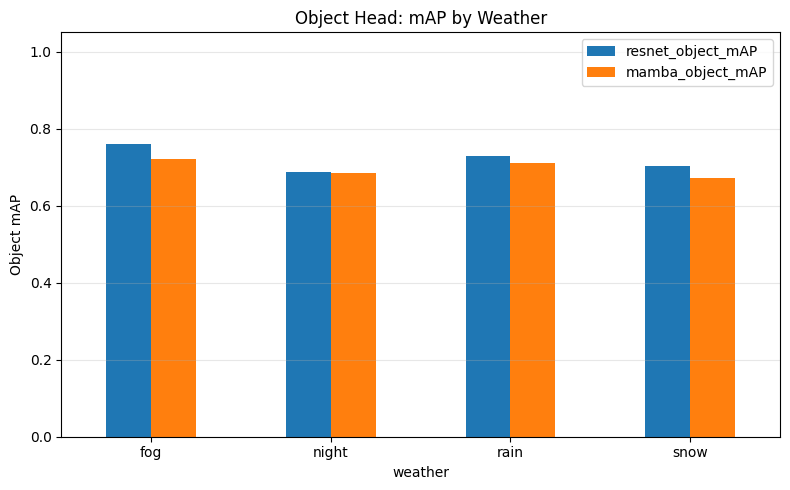

In [9]:
weather_plot = weather_cmp.set_index("weather")[["resnet_object_mAP", "mamba_object_mAP"]]
ax = weather_plot.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Object mAP")
ax.set_title("Object Head: mAP by Weather")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "per_weather_map_comparison.png", dpi=200)
plt.show()

## Training Loss Curves

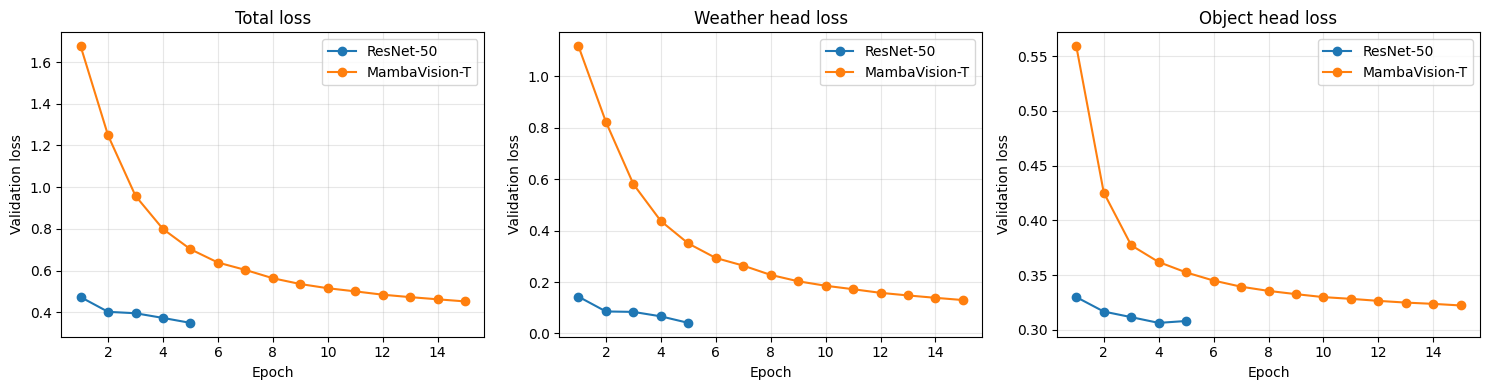

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)

loss_specs = [
    ("total_loss", "Total loss"),
    ("weather_loss", "Weather head loss"),
    ("object_loss", "Object head loss"),
]

for ax, (suffix, title) in zip(axes, loss_specs):
    for model_name, history in histories.items():
        label = "ResNet-50" if model_name == "resnet50" else "MambaVision-T"
        ax.plot(history["epoch"], history[f"val_{suffix}"], marker="o", label=label)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "validation_loss_comparison.png", dpi=200)
plt.show()

## Export Comparison Tables

In [11]:
summary.to_csv(OUT_DIR / "summary_metrics.csv")
comparison.to_csv(OUT_DIR / "summary_metrics_with_delta.csv")

print("Saved comparison outputs to:", OUT_DIR)
for path in sorted(OUT_DIR.glob("*.csv")):
    print("-", path.name)
for path in sorted(OUT_DIR.glob("*.png")):
    print("-", path.name)

Saved comparison outputs to: /content/comparison_outputs
- per_class_comparison.csv
- per_weather_comparison.csv
- summary_metrics.csv
- summary_metrics_with_delta.csv
- per_class_ap_comparison.png
- per_weather_map_comparison.png
- summary_metrics_comparison.png
- validation_loss_comparison.png
